In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src.features import make_features, make_targets, attach_store_data
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

N_STORES = 3
DAYS     = 500
FORECAST_HORIZON = 15

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)

def make_synthetic_sales_data():
    dates    = pd.date_range("2013-01-01", periods=DAYS, freq="D")
    rows = []
    rng  = np.random.default_rng(C.SEED)
    for store_id in range(1, N_STORES + 1):
        base = 300 + store_id * 150          # stores differ in overall level
        for date in dates:
            dow      = date.dayofweek + 1    # 1=Mon … 7=Sun
            is_sun   = dow == 7
            seasonal = base + 20 * np.sin(2 * np.pi * (dow - 1) / 6)   # peak Wed
            trend    = 0.2 * (date - dates[0]).days
            promo    = int(rng.random() < 0.25)
            sales    = max(0.0, seasonal + trend + promo * 100) if not is_sun else 0.0
            rows.append({
                "Date":          date,
                "Store":         store_id,
                "DayOfWeek":     dow,
                "Open":          0 if is_sun else 1,
                "Promo":         promo,
                "StateHoliday":  "0",
                "SchoolHoliday": 0,
                "Sales":         sales,
            })

    train = pd.DataFrame(rows)

    return train

def make_synthetic_store_data():

    stores = pd.DataFrame({
        "Store":               list(range(1, N_STORES + 1)),
        "StoreType":           ["a", "b", "c"],
        "Assortment":          ["a", "a", "b"],
        "CompetitionDistance": [500.0, 1200.0, 800.0],
        "CompetitionSinceDate": pd.to_datetime(["2012-03-01", "2011-06-01", "2013-01-01"]),
        "Promo2SinceDate":     pd.to_datetime(["2012-06-01", pd.NaT,       "2013-03-01"]),
        "PromoInterval":       ["Jan,Apr,Jul,Oct", None,                   "Mar,Jun,Sep,Dec"],
    })

    return stores


c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate  Promo2
         2     1      0            0              0 467.320508         a          a                500.0           2012-03-01      2012-06-01       1
         3     1      0            0              0 467.520508         a          a                500.0           2012-03-01      2012-06-01       1
         4     1      0            0              0 450.400000         a          a                500.0           2012-03-01      2012-06-01       1
         5     1      0            0              0 433.279492         a          a                500.0           2012-03-01      2012-06-01       1
         6     1      1            0              0 533.479492         a          a                500.0           2012-03-01      2012-06-01       1


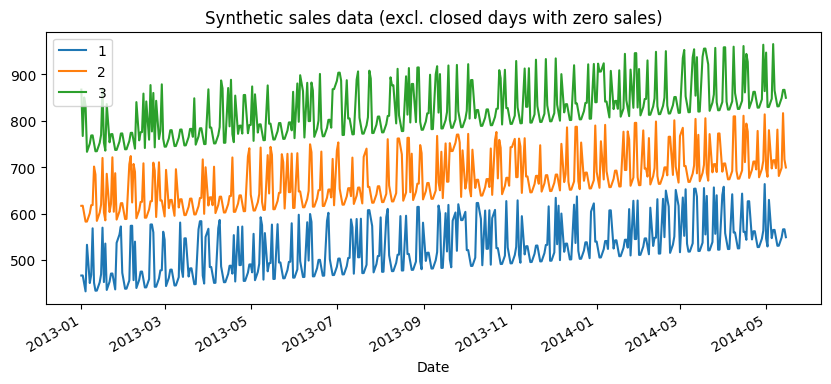

In [2]:
stores = make_synthetic_store_data()
train = make_synthetic_sales_data()
df  = attach_store_data(train, stores).set_index(["Date", "Store"])

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "outer_train_size": 150, #C.OUTER_TRAIN_SIZE,
    "inner_train_size": 80, #C.INNER_TRAIN_SIZE,
}

study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [3]:
cv_config

{'n_outer_splits': 6,
 'n_inner_splits': 4,
 'forecast_horizon': 15,
 'outer_train_size': 150,
 'inner_train_size': 80}

In [4]:

# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. Log-transform the target
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)
df['Sales'] = utils.overwrite_closed_sales(df['Sales'], mode='interpolate').apply(np.log1p)
X = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
y = make_targets(df['Sales'], C.FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                    horizon=cv_config["forecast_horizon"],
                    train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    #hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config, C.REFIT_VAL_FRACTION)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = hypertuning.predict(booster, X_test)
    
    # Log metrics
    actuals_index = preds.index.droplevel("Date").swaplevel("Store")  # Align with original df index to get actual sales
    actuals = df.loc[actuals_index, 'Sales'].apply(np.expm1)
    actuals = utils.overwrite_closed_sales(actuals, mode='zero')  # Set actual sales to zero for closed days
    metrics = compute_metrics(actuals.values, preds.values)
    metrics = {metric: round(value, 3) for metric, value in metrics.items()}
    logger.info(f"Test set metrics for fold {fold}: {metrics}")

    # Save artifacts
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break


[0]	val-rmse:0.23227
[1]	val-rmse:0.20800
[2]	val-rmse:0.18688
[3]	val-rmse:0.16854
[4]	val-rmse:0.15264
[5]	val-rmse:0.13900
[6]	val-rmse:0.12734
[7]	val-rmse:0.11718
[8]	val-rmse:0.10852
[9]	val-rmse:0.10113
[10]	val-rmse:0.09772
[11]	val-rmse:0.09463
[12]	val-rmse:0.09201
[13]	val-rmse:0.08713
[14]	val-rmse:0.08507
[15]	val-rmse:0.08118
[16]	val-rmse:0.08121
[17]	val-rmse:0.08111
[18]	val-rmse:0.08124
[19]	val-rmse:0.08125
[20]	val-rmse:0.08126
[21]	val-rmse:0.08132
[22]	val-rmse:0.08144
[23]	val-rmse:0.08135
[24]	val-rmse:0.08145
[25]	val-rmse:0.08149
[26]	val-rmse:0.08147


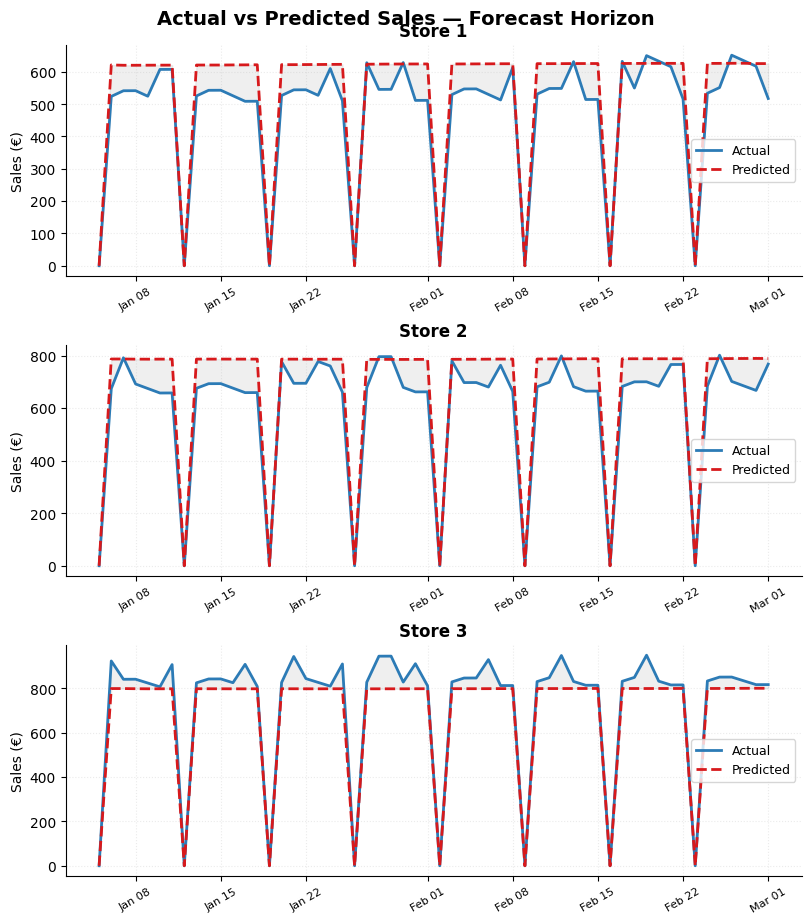

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Build a proper comparison df: look up actuals on the forecast dates from df
actuals_idx = preds.index.droplevel("Date").swaplevel()  # (Forecast Date, Store)
true_vals = df.loc[actuals_idx, "Sales"].apply(np.expm1)
true_vals = utils.overwrite_closed_sales(true_vals, mode='zero')
true_vals.index = preds.index

comp = (
    pd.DataFrame({"Actual": true_vals.values, "Predicted": preds.values}, index=preds.index)
    .reset_index()
    .groupby(["Store", "Forecast Date"])[["Actual", "Predicted"]]
    .mean()
    .reset_index()
)

selected_stores = sorted(comp["Store"].unique())[:6]
ncols = 1
nrows = -(-len(selected_stores) // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 3 * nrows), constrained_layout=True)
axes = axes.flatten()

for ax, store_id in zip(axes, selected_stores):
    d = comp[comp["Store"] == store_id].sort_values("Forecast Date")
    ax.plot(d["Forecast Date"], d["Actual"],    label="Actual",    color="#2c7bb6", lw=2)
    ax.plot(d["Forecast Date"], d["Predicted"], label="Predicted", color="#d7191c", lw=2, ls="--")
    ax.fill_between(d["Forecast Date"], d["Actual"], d["Predicted"],
                    alpha=0.12, color="gray")
    ax.set_title(f"Store {store_id}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Sales (€)", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.spines[["top", "right"]].set_visible(False)

# Hide any unused axes
for ax in axes[len(selected_stores):]:
    ax.set_visible(False)

fig.suptitle("Actual vs Predicted Sales — Forecast Horizon", fontsize=14, fontweight="bold", y=1.01)
plt.show()
